# Change detection in optical satellite time series - Tutorial

<div align="center">
  
  <!-- Institution Logos -->
  <img src="https://www.umr-lastig.fr/static/lastig_1920_EN-5022e6685c1e4b6d7e84d2a08667be4e.png" height="60" alt="LASTIG">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://iadf-school.org/wp-content/uploads/2022/09/logo_iadfschool.png" height="60" alt="IADF School">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://design-system.ign.fr/img/styleguide/sg_logos/IGN_logo_RVB.png" height="60" alt="IGN">
  
  <br><br>
  
  <!-- Colab Badge -->
  [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ElliotVincent/iadf_tutorial/blob/main/tutorial_3.ipynb)
  
  
</div>

---

## **Tutorial 2: Training and Evaluating bi- and multi-temporal change detection models**

**Welcome to Tutorial 2!** In this hands-on session, you will learn how to train and evaluate bi- and multi-temporal change detection models for optical satellite image time series (SITS).

### What You'll Learn
- Working with a toy dataset of Planet multispectral imagery
-
- Train a semantic segmentation model
- Evaluating model performance in a post-classification framework
- Practical implementation in Google Colab

### Prerequisites
- Basic knowledge of Python and deep learning
- Familiarity with remote sensing concepts
- Google account for Colab access

---

## Introduction

This tutorial demonstrates how to perform change detection in optical satellite time series using Python.  
We will use a sample dataset of satellite images and apply various techniques to identify changes over time.  
The sample dataset is extracted from DynamicEarthNet [1] and focuses on 3 AoIs.  
The map below shows the location of the 3 AoIs in the world:  


![Map of the 3 AoIs](https://github.com/ElliotVincent/iadf_tutorial/blob/main/aois_location.png?raw=1)


In [1]:
# Import necessary libraries
import copy
import matplotlib.pyplot as plt
import numpy as np
import random
import rasterio
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
!pip install segmentation_models_pytorch -q
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.base import SegmentationModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.8 MB/s eta 0:00:00


## 1. Playing with Satellite Image Time Series

### 1.1. Loading and Visualizing the Dataset

In [2]:
DYNAMICEARTHNET_CLASSES = {
    0: {"label": "other",                     "color": (128, 128, 128)},  # grey
    1: {"label": "vegetation",                "color": ( 34, 139,  34)},  # green
    2: {"label": "water",                     "color": ( 31, 119, 180)},  # blue
}

DATES = [f"{yyyy}-{mm:02d}-01" for yyyy in range(2018, 2020) for mm in range(1, 13)]
DATES_S2 = [f"{yyyy}_{mm:02d}" for yyyy in range(2018, 2020) for mm in range(1, 13)]

# Utility function to perform percentile stretching on the image for better visualization
def percentile_stretch(img, low=2, high=98):
    lo, hi = np.percentile(img, (low, high))
    img_clipped = np.clip(img, lo, hi)
    return ((img_clipped - lo) / (hi - lo) * 255).astype(np.uint8)

# Function to plot a single image
def plot_image(image):
    rgb_img = image[:3]
    rgb_img = rgb_img.transpose(1, 2, 0)
    rgb_img = percentile_stretch(rgb_img)
    plt.imshow(rgb_img)
    plt.axis('off')

# Function to plot a single label
def plot_labels(label):
    rgb_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for i in range(3):
        rgb_label[label == i] = DYNAMICEARTHNET_CLASSES[i]["color"]
    plt.imshow(rgb_label)
    plt.axis('off')

# Function to plot a time series of images and labels
def plot_time_series(images, labels, num_images=10):
    num_images = min(num_images, len(images))
    fig, axes = plt.subplots(3, num_images, figsize=(int(4*num_images / 3), 4))
    for i in range(num_images):
        # Plot the image
        rgb_img = images[i, :3].transpose(1, 2, 0)
        rgb_img = percentile_stretch(rgb_img)
        axes[0, i].set_title(DATES[i], fontsize=10)
        axes[0, i].imshow(rgb_img)
        axes[0, i].axis('off')

        # Plot the semantic maps
        rgb_label = np.zeros((labels[i].shape[0], labels[i].shape[1], 3), dtype=np.uint8)
        for j in range(3):
            rgb_label[labels[i] == j] = DYNAMICEARTHNET_CLASSES[j]["color"]
        axes[1, i].imshow(rgb_label)
        axes[1, i].axis('off')

        # Plot binary change maps
        if i > 0:
            change_map = (labels[i] != labels[i-1]).astype(np.uint8) * 255
            axes[2, i].imshow(change_map, cmap='gray')
            axes[2, i].axis('off')
        else:
            axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()

def load_time_series(path):
    return np.stack([rasterio.open(f"{path}/{date}.tif").read() for date in DATES], axis=0)[:, [2, 1, 0, 3]]

def load_time_series_s2(path):
    return np.stack([rasterio.open(f"{path}/{date}.tif").read() for date in DATES_S2], axis=0)[:, [0, 1, 2, 3, 4, 5, 6, 7, 10, 11]]

def load_labels(path):
    labels = np.load(f'{path}.npy')
    labels = np.where(labels == 2, 1, labels)
    labels = np.where(labels == 3, 0, labels)
    labels = np.where(labels == 4, 0, labels)
    labels = np.where(labels == 5, 2, labels)
    labels = np.where(labels == 6, 0, labels)
    return labels

We first load the sample dataset and visualize the images for each AoI.  
Satellite image time series (SITS) are stored as T x C x H x W tensors, where T is the number of time steps, C is the number of channels (spectral bands), H is the height, and W is the width of the image.  
In our case, we have 3 AoIs with T=24 (2 years of monthly images between January 2018 and December 2019), C=4 (RGB + NIR), H=1024, and W=1024.  
The spatial resolution of the images is roughly 3 meters per pixel.
DinamicEarthNet dataset is annotated with per-month semantic masks, with 7 land-cover classes: Impervious surface, Agriculture, Forest, Bare soil, Wetlands, Water, Snow/Ice.  
In this tutorial, we simplify the problem by grouping them in 3 classes:
- 0: Other (Impervious surface + Bare soil + Wetlands + Snow/Ice)
- 1: Vegetation (Agriculture + Forest)
- 2: Water (Water)

In [3]:
!gdown 1CcQKjFKLIgVqQ1df_hFMWQoHfwAKfpLn
!gdown 1imnmKsAG83CJbddoQrKhx58ubB0XXV04
!gdown 1DHtHnyZHexnEMyN0TPmooUToM277uC0f
!unzip "/content/data.zip"
!unzip "/content/data_s2.zip"
!unzip "/content/labels.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1CcQKjFKLIgVqQ1df_hFMWQoHfwAKfpLn
From (redirected): https://drive.google.com/uc?id=1CcQKjFKLIgVqQ1df_hFMWQoHfwAKfpLn&confirm=t&uuid=cf9ffb58-9d80-408c-b155-37889bc2de19
To: /content/data.zip
100% 171M/171M [00:07<00:00, 23.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1imnmKsAG83CJbddoQrKhx58ubB0XXV04
To: /content/labels.zip
100% 1.15M/1.15M [00:00<00:00, 7.33MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1DHtHnyZHexnEMyN0TPmooUToM277uC0f
From (redirected): https://drive.google.com/uc?id=1DHtHnyZHexnEMyN0TPmooUToM277uC0f&confirm=t&uuid=2ece3fab-4ba7-4f23-b420-e3ccd5c6c551
To: /content/data_s2.zip
100% 326M/326M [00:12<00:00, 27.1MB/s]
Archive:  /content/data.zip
   creating: 3998_3016_13/
  inflating: 3998_3016_13/2019-07-01.tif  
  inflating: 3998_3016_13/2018-01-01.tif  
  inflating: 3998_3016_13/2019-01-01.tif  
  inflating: 3998_3016_13/2018-02-01.tif  
  inflating: 3998_3016_13/2018-

Loading images and labels...


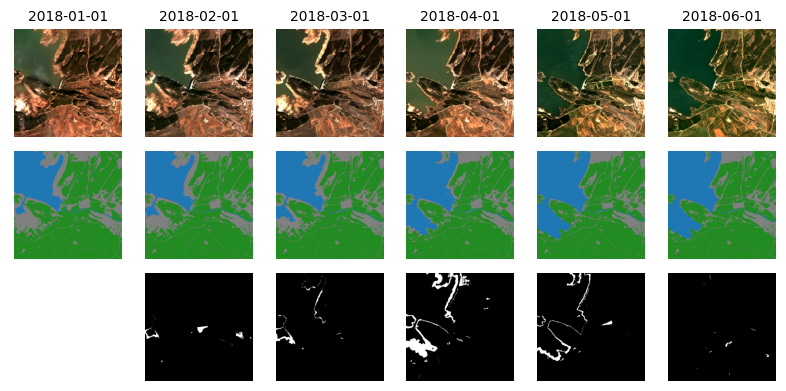

In [4]:
aoi_name = '3998_3016_13'

print(f"Loading images and labels...")
images = load_time_series(aoi_name)
images_s2 = load_time_series_s2(aoi_name)
labels = load_labels(aoi_name)
plot_time_series(images, labels, num_images=6)

Let's check the shape of each SITS tensor.

In [5]:
print(f"Images shape: {images.shape}, labels shape: {labels.shape}")

Images shape: (24, 4, 1024, 1024), labels shape: (24, 1024, 1024)


In [6]:
class SITSDataset(torch.utils.data.Dataset):
    def __init__(self, data, data_s2, labels, split, norm=True, num_classes=3, augment=False):
        # Load the dataset once in memory
        self.data = data
        self.data_s2 = data_s2
        self.labels = labels
        self.norm = norm
        # Dataset statistics for normalization, from DynamicEarthNet paper
        self.mean = torch.tensor([1042.59, 915.62, 671.26, 2605.21,
                                  1105, 1355, 1552, 1887, 2422, 2630, 2743, 2785, 2388, 1835])
        self.std = torch.tensor([957.96, 715.55, 596.94, 1059.90,
                                 1809, 1757, 1888, 1870, 1732, 1697, 1742, 1648, 1470, 1379])
        self.num_classes = num_classes
        self.ij_lists = {"train":[[i, j] for i in range(16) for j in range(16) if j >= 8 or i < 8],
                         "val": [[i, j] for i in range(16) for j in range(16) if i >= 12 and j < 8],
                         "test": [[i, j] for i in range(16) for j in range(16) if i >= 8 and i < 12 and j < 8]}[split]
        self.split = split
        self.augment = augment

    def __len__(self):
        return len(self.ij_lists)

    def __getitem__(self, idx):
        i, j = self.ij_lists[idx]
        x, y = i*64, j*64
        if self.split == 'train' and self.augment:
          # random crop
          x = min(x + random.randint(0, 63), 7 * 64) if j < 8 else min(x + random.randint(0, 63), 15 * 64)
          y = min(y + random.randint(0, 63), 15 * 64)
        imgs = torch.tensor(self.data[..., x:x+64, y:y+64])
        imgs_s2 = torch.tensor(self.data_s2[..., x:x+64, y:y+64])
        imgs = torch.cat([imgs, imgs_s2], dim=1)
        labs = torch.tensor(self.labels[..., x:x+64, y:y+64])
        if self.norm:
            imgs = (imgs - self.mean[:, None, None]) / self.std[:, None, None]
        if self.augment:
            # random rotation
            rot = random.randint(0, 3)
            imgs = torch.rot90(imgs, rot, [2, 3])
            labs = torch.rot90(labs, rot, [1, 2])
            # random flip
            flip = random.randint(0, 1)
            if flip == 1:
                imgs = torch.flip(imgs, [2])
                labs = torch.flip(labs, [1])
        return imgs, labs

In [7]:
train_set = SITSDataset(data=images,
                        data_s2=images_s2,
                        labels=labels,
                        split='train', norm=True, num_classes=3, augment=True)

val_set = SITSDataset(data=images,
                      data_s2=images_s2,
                      labels=labels,
                      split='val', norm=True, num_classes=3)

test_set = SITSDataset(data=images,
                      data_s2=images_s2,
                      labels=labels,
                      split='test', norm=True, num_classes=3)

print(f"Train dataset length: {len(train_set)}")
print(f"Validation dataset length: {len(val_set)}")
print(f"Test dataset length: {len(test_set)}")

Train dataset length: 192
Validation dataset length: 32
Test dataset length: 32


In [8]:
def compute_metrics(confusion_matrix):
    # Compute overall accuracy
    overall_accuracy = torch.trace(confusion_matrix) / torch.sum(confusion_matrix)

    # Compute mean IoU
    intersection = torch.diagonal(confusion_matrix)
    union = torch.sum(confusion_matrix, dim=1) + torch.sum(confusion_matrix, dim=0) - intersection
    mean_iou = torch.mean(intersection / union)

    return overall_accuracy, mean_iou


class ScaledDotProductAttention(nn.Module):
    """Scaled Dot-Product Attention
    Modified from github.com/jadore801120/attention-is-all-you-need-pytorch
    """

    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)
        self.softmax = nn.Softmax(dim=2)

    def forward(self, q, k, v):
        attn = torch.matmul(k, q)
        attn = attn / self.temperature
        attn = self.softmax(attn)
        attn = self.dropout(attn)
        output = torch.matmul(attn, v)
        return output, attn


class MultiDualUnet(nn.Module):
    def __init__(self, backbone="mobilenet_v2", in_channels=4, num_classes=3):
        super(MultiDualUnet, self).__init__()
        self.change_model = smp.Unet(encoder_name=backbone, encoder_weights="imagenet", in_channels=in_channels * 2, classes=2)
        self.seg_model   = smp.Unet(encoder_name=backbone, encoder_weights="imagenet", in_channels=in_channels, classes=num_classes)

        self.n_head = 4
        self.d_k    = 8
        self.d_in   = 1280

        self.fc1_q = nn.Linear(self.d_in, self.n_head * self.d_k)
        nn.init.normal_(self.fc1_q.weight, mean=0, std=np.sqrt(2.0 / self.d_k))

        self.fc1_k = nn.Linear(self.d_in, self.n_head * self.d_k)
        nn.init.normal_(self.fc1_k.weight, mean=0, std=np.sqrt(2.0 / self.d_k))

        self.attention = ScaledDotProductAttention(temperature=np.power(self.d_k, 0.5))

        self.pos_enc_proj = nn.Sequential(
            nn.Linear(self.d_in, self.d_in),  # input: sinusoidal features
            nn.GELU(),
            nn.Linear(self.d_in, self.d_in),
        )

        # Discover encoder depth with a dummy forward pass
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 64, 64)
            n_levels = len(self.seg_model.encoder(dummy))

        # Pre-initialize all gates — these will move correctly with .to(device) / .cuda()
        self.temporal_gates = nn.ParameterDict({
            str(i): nn.Parameter(torch.full((1,), -1.0))
            for i in range(1, n_levels)
        })

    def _get_gate(self, level_idx):
        return torch.sigmoid(self.temporal_gates[str(level_idx)])

    def days_to_sinusoidal(self, days, d_model):
        """
        days: B x T  (absolute day indices, float or long)
        Returns: B x T x d_model sinusoidal encoding.

        Uses periods tuned for satellite time series:
        - Short periods (days–weeks) capture phenological cycles
        - Long periods (months–years) capture seasonal/inter-annual patterns
        The day count is normalized by 365.25 so period=1 = annual cycle.
        """
        d_half = d_model // 2
        # Log-spaced frequencies from 1/365 (annual) down to 1/1 (daily)
        # covering multi-year to sub-weekly patterns
        freqs = torch.exp(
            torch.linspace(
                np.log(1.0 / 730),   # slowest: 1 cycle/year
                np.log(1.0),             # fastest: 1 cycle/day
                d_half,
                device=days.device
            )
        )                                                  # d_half
        # days: B x T → B x T x d_half
        angles = days.float().unsqueeze(-1) * freqs        # B x T x d_half
        enc = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # B x T x d_model
        return enc

    def forward(self, x, days):
        """
        x:    B x T x C x H x W
        days: B x T  — absolute day index of each acquisition, e.g. [[24, 85, 100], ...]
        """
        B, T, C, H, W = x.shape

        features = self.seg_model.encoder(x.reshape(-1, C, H, W))
        features = [f.reshape(B, T, *f.shape[1:]) for f in features]

        # days passed straight into attention
        out_features, att = self.multihead_temporal_attention_model(features[-1], days)

        # Propagate attention to intermediate encoder features
        attended_features = [self._get_gate(len(features) - 1) * out_features + (1.0 - self._get_gate(len(features) - 1) * features[-1])]
        for i in range(len(features) - 2, 0, -1):
            agg  = self.temporal_attention_aggregation(features[i], att)
            gate = self._get_gate(i)
            # FIX 4: convex combination of attended and raw features.
            # At init, gate ≈ 0 → model behaves like DualUnet.
            # Gradients will open the gate only if temporal mixing helps.
            blended = gate * agg + (1.0 - gate) * features[i]
            attended_features = [blended] + attended_features
        attended_features = [features[0]] + attended_features

        out_features_reshaped = [f.reshape(B * T, -1, f.shape[-2], f.shape[-1]) for f in attended_features]
        seg_logits = self.seg_model.decoder(out_features_reshaped)
        seg_logits = self.seg_model.segmentation_head(seg_logits)
        seg_logits = seg_logits.view(B, T, *seg_logits.shape[1:])

        # --- Change detection branch ---
        # FIX 3: use raw encoder features (not attention-aggregated) for the change signal,
        # mirroring what DualUnet does. The attention-aggregated features mix temporal context
        # across all timesteps, which corrupts the pairwise difference signal.
        change_features = self.change_model.encoder(
            torch.cat([x[:, :-1].reshape(-1, C, H, W),
                       x[:, 1: ].reshape(-1, C, H, W)], dim=1)
        )
        change_features = [f.reshape(B, (T - 1), -1, f.shape[-2], f.shape[-1]) for f in change_features]

        for i, feat in enumerate(change_features):
            if i > 0:
                # Use raw encoder features for the semantic residual, not attended ones
                change_features[i] = feat + features[i][:, :-1] - features[i][:, 1:]

        change_features_reshaped = [f.reshape(B * (T - 1), -1, f.shape[-2], f.shape[-1]) for f in change_features]
        change_logits = self.change_model.decoder(change_features_reshaped)
        change_logits = self.change_model.segmentation_head(change_logits)
        change_logits = change_logits.view(B, T - 1, *change_logits.shape[1:])

        return seg_logits, change_logits

    def multihead_temporal_attention_model(self, x, days):
        """
        x:    B x T x D x H x W
        days: B x T  e.g. [[24, 85, 100, ...], ...]
        """
        sz_b, seq_len, d, h, w = x.shape
        v = x.permute(0, 3, 4, 1, 2).contiguous().view(sz_b * h * w, seq_len, d)

        # B x T x D sinusoidal encoding from raw day indices
        pos = self.days_to_sinusoidal(days, self.d_in)   # B x T x D
        pos = self.pos_enc_proj(pos)                      # B x T x D

        # Expand to match flattened spatial dim: B*H*W x T x D
        pos = pos.unsqueeze(1).unsqueeze(1).expand(-1, h, w, -1, -1)  # B x H x W x T x D
        pos = pos.contiguous().view(sz_b * h * w, seq_len, d)

        # Inject into Q and K only
        v_pos = v + pos

        q = self.fc1_q(v_pos).view(sz_b * h * w, seq_len, self.n_head, self.d_k)
        q = q.permute(2, 0, 1, 3).contiguous().view(-1, seq_len, self.d_k).permute(0, 2, 1)

        k = self.fc1_k(v_pos).view(sz_b * h * w, seq_len, self.n_head, self.d_k)
        k = k.permute(2, 0, 1, 3).contiguous().view(-1, seq_len, self.d_k)

        # V uses original v (no positional encoding)
        v = torch.stack(v.split(v.shape[-1] // self.n_head, dim=-1)).view(
            self.n_head * sz_b * h * w, seq_len, -1
        )

        output, attn = self.attention(q, k, v)
        attn   = attn.view(self.n_head, sz_b * h * w, seq_len, seq_len)
        output = output.view(self.n_head, sz_b * h * w, seq_len, self.d_in // self.n_head)

        out = output.permute(1, 2, 0, 3).contiguous().view(sz_b * h * w, seq_len, -1)
        out = out.view(sz_b, h, w, seq_len, -1).permute(0, 3, 4, 1, 2)

        attn = attn.view(self.n_head, sz_b, h, w, seq_len, seq_len).permute(0, 1, 4, 5, 2, 3)
        return out, attn

    def temporal_attention_aggregation(self, x, attn_mask):
        n_heads, b, t, _, h, w = attn_mask.shape

        # Resize attention mask to match x's spatial resolution
        attn = attn_mask.contiguous().view(n_heads * b * t, t, h, w)
        if x.shape[-2] > w:
            attn = nn.Upsample(size=x.shape[-2:], mode="bilinear", align_corners=False)(attn)
        else:
            attn = nn.AvgPool2d(kernel_size=w // x.shape[-2])(attn)
        attn = attn.view(n_heads, b, t, t, *x.shape[-2:])  # n_head x B x T x T x H x W

        # FIX 2: correct aggregation — sum over KEY time dim (dim=3), not query dim
        # attn[n,b,tq,tk,h,w]: weight of key tk when forming query tq's output
        # x split across heads: n_head x B x T x (C/n_head) x H x W
        out = torch.stack(x.chunk(n_heads, dim=2))               # n_head x B x T x (C/h) x H x W
        # Weighted sum: for each query timestep tq, aggregate key timesteps tk
        # einsum: attn(n,b,tq,tk,h,w) * out(n,b,tk,c,h,w) → sum over tk → (n,b,tq,c,h,w)
        out = torch.einsum('nbqkhw, nbkchw -> nbqchw', attn, out)  # FIX 2: q=query, k=key index
        out = torch.cat([group for group in out], dim=2)            # B x T x C x H x W
        return out

In [9]:
model = MultiDualUnet()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Model parameters: 16,621,402


In [11]:
device = 'cuda'
DAYS = torch.tensor([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365, 396, 424, 455, 485, 516, 546, 577, 608, 638, 669, 699], device=device)

def training_step(batch, model, criterion, optimizer, device):
    imgs, labs = batch
    imgs = imgs.to(device)
    labs = labs.to(device)
    # imgs of shape (B, T, C, H, W)
    optimizer.zero_grad()
    temp_indices = torch.tensor([random.sample(range(imgs.size(1)), 6) for _ in range(imgs.size(0))], device=imgs.device)  # (B, 2)
    temp_indices, _ = torch.sort(temp_indices, dim=1)
    batch_idx = torch.arange(imgs.size(0), device=imgs.device)[:, None]
    imgs, labs, days = imgs[batch_idx, temp_indices], labs[batch_idx, temp_indices], DAYS[None].expand((imgs.size(0), -1))[batch_idx, temp_indices]
    sem_logits, change_logits = model(imgs, days)
    change_gt = nn.functional.one_hot((labs[:, :-1] != labs[:, 1:]).long(), num_classes=2).permute(0, 1, 4, 2, 3).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits.reshape(-1, 2, 64, 64), change_gt.reshape(-1, 2, 64, 64), reduction='mean')
    loss_sem = criterion(sem_logits.reshape(-1, 3, 64, 64), labs.long().reshape(-1, 64, 64))
    loss = loss_change + loss_sem
    loss.backward()
    optimizer.step()
    return loss


def validation_step(batch, model, criterion, device):
    imgs, labs = batch
    imgs = imgs.to(device)
    labs = labs.to(device).squeeze(0)
    # imgs of shape (1, T, C, H, W)
    sem_logits, change_logits = model(imgs, DAYS.unsqueeze(0))
    change_gt = nn.functional.one_hot((labs[:-1] != labs[1:]).long(), num_classes=2).permute(0, 3, 1, 2).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits.reshape(-1, 2, 64, 64), change_gt.reshape(-1, 2, 64, 64), reduction='mean')
    loss_sem = criterion(sem_logits.reshape(-1, 3, 64, 64), labs.long().reshape(-1, 64, 64))
    loss = loss_change + loss_sem
    pred_sem = torch.argmax(sem_logits.squeeze(0), dim=1)
    pred_change = torch.argmax(change_logits.squeeze(0), dim=1)
    return loss, pred_change, pred_sem, (labs[:-1] != labs[1:]).long(), labs.long()

In [12]:
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False)
model = MultiDualUnet(in_channels=14)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
num_epochs = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
device = 'cuda'
DAYS = torch.tensor([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365, 396, 424, 455, 485, 516, 546, 577, 608, 638, 669, 699], device=device)
model.to(device)

logs = {"train_loss": [], "val_loss": [], "val_acc": [], "val_miou": [], "val_iou_change": [], "learning_rate": []}
best_val_iou_change = 0.0
best_model_change = None
best_model_val_conf_matrix = None
best_model_val_conf_matrix_change = None

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()
    avg_train_loss = 0.0
    for batch in train_loader:
        loss = training_step(batch, model, criterion, optimizer, device)
        avg_train_loss += loss.item()
    avg_train_loss /= len(train_loader)
    print(f"   Average Training Loss: {avg_train_loss:.4f}")

    model.eval()
    avg_val_loss = 0.0
    val_conf_matrix = torch.zeros(3, 3, dtype=torch.long, device=device)
    val_conf_matrix_change = torch.zeros(2, 2, dtype=torch.long, device=device)
    with torch.no_grad():
        for batch in val_loader:
            loss, pred_change, pred_sem, labs_change, labs_sem = validation_step(batch, model, criterion, device)
            avg_val_loss += loss.item()
            val_conf_matrix += torch.bincount(pred_sem.flatten().long() * 3 + labs_sem.flatten().long(), minlength=9).reshape(3, 3)
            val_conf_matrix_change += torch.bincount(pred_change.flatten().long() * 2 + labs_change.flatten().long(), minlength=4).reshape(2, 2)
    avg_val_loss /= len(val_loader)
    acc, miou = compute_metrics(val_conf_matrix)
    iou_change = val_conf_matrix_change[1, 1] / (val_conf_matrix_change[1, 1] + val_conf_matrix_change[1, 0] + val_conf_matrix_change[0, 1])
    print(f"   Average Validation Loss: {avg_val_loss:.4f}")
    print(f"   Validation Accuracy: {acc*100:.2f}%, mIoU: {miou*100:.2f}%")
    print(f"   Change IoU: {iou_change*100:.2f}%")
    logs["train_loss"].append(avg_train_loss)
    logs["val_loss"].append(avg_val_loss)
    logs["val_acc"].append(acc.item())
    logs["val_miou"].append(miou.item())
    logs["val_iou_change"].append(iou_change.item())
    if iou_change.item() > best_val_iou_change:
        best_val_iou_change = iou_change.item()
        best_model_change = copy.deepcopy(model)
        best_model_val_conf_matrix = val_conf_matrix.clone()
        best_model_val_conf_matrix_change = val_conf_matrix_change.clone()
    logs["learning_rate"].append(optimizer.param_groups[0]["lr"])
    scheduler.step()

Epoch 1/50
   Average Training Loss: 0.8094
   Average Validation Loss: 0.7032
   Validation Accuracy: 74.55%, mIoU: 29.18%
   Change IoU: 0.55%
Epoch 2/50
   Average Training Loss: 0.5253
   Average Validation Loss: 0.4501
   Validation Accuracy: 80.95%, mIoU: 46.47%
   Change IoU: 0.06%
Epoch 3/50
   Average Training Loss: 0.4729
   Average Validation Loss: 0.2856
   Validation Accuracy: 91.85%, mIoU: 53.45%
   Change IoU: 0.13%
Epoch 4/50
   Average Training Loss: 0.4250
   Average Validation Loss: 0.2633
   Validation Accuracy: 92.48%, mIoU: 60.82%
   Change IoU: 0.00%
Epoch 5/50
   Average Training Loss: 0.4146
   Average Validation Loss: 0.2609
   Validation Accuracy: 90.95%, mIoU: 62.31%
   Change IoU: 0.38%
Epoch 6/50
   Average Training Loss: 0.4228
   Average Validation Loss: 0.2580
   Validation Accuracy: 92.49%, mIoU: 66.69%
   Change IoU: 4.68%
Epoch 7/50
   Average Training Loss: 0.4206
   Average Validation Loss: 0.2556
   Validation Accuracy: 92.20%, mIoU: 67.46%
   Cha

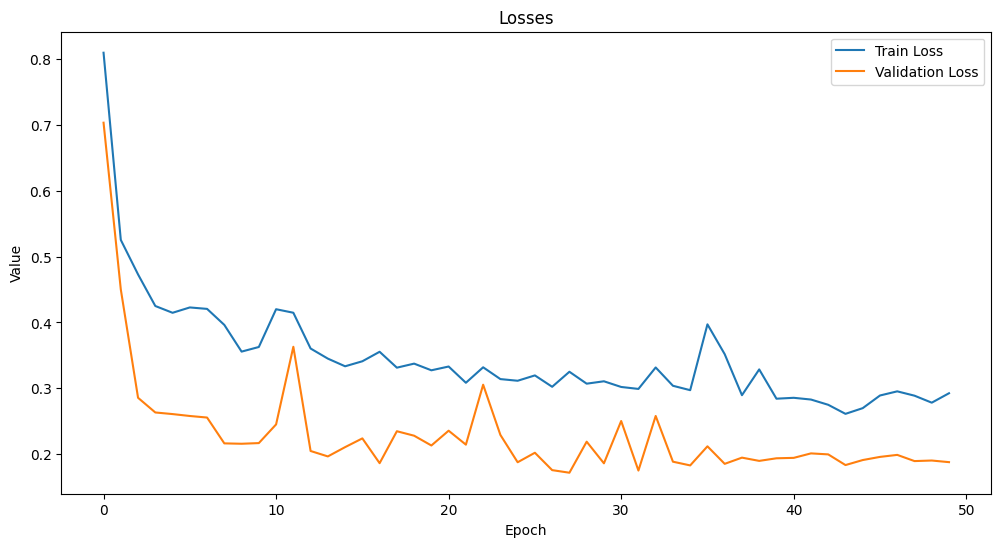

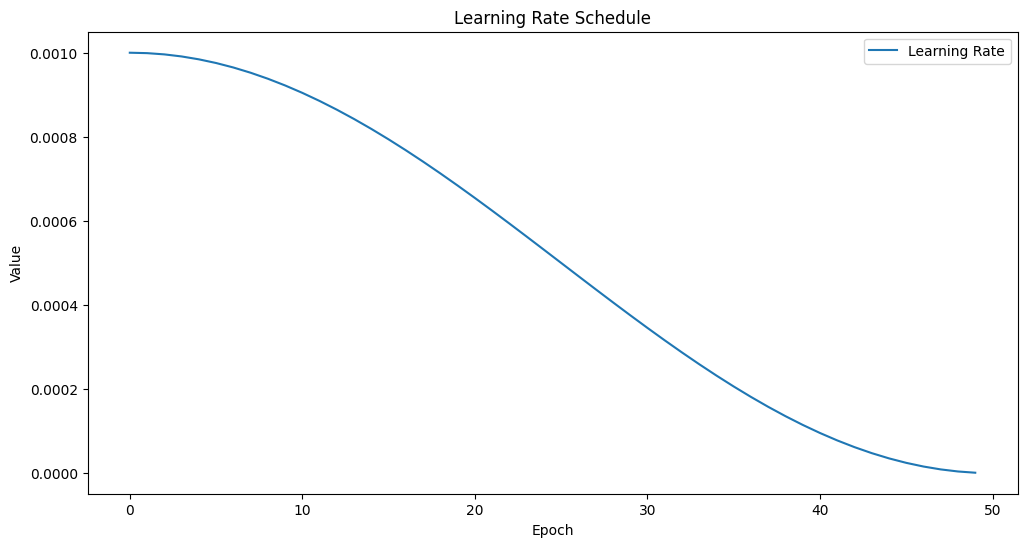

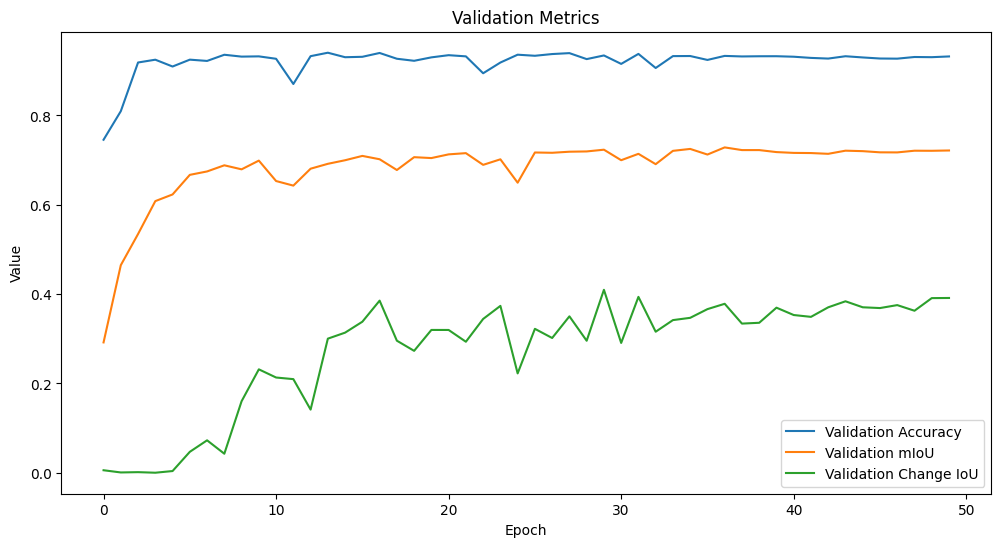

In [13]:
# Visualize the trainng curves
plt.figure(figsize=(12, 6))
plt.plot(logs["train_loss"], label="Train Loss")
plt.plot(logs["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Losses")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(logs["learning_rate"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(logs["val_acc"], label="Validation Accuracy")
plt.plot(logs["val_miou"], label="Validation mIoU")
plt.plot(logs["val_iou_change"], label="Validation Change IoU")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Validation Metrics")
plt.legend()
plt.show()

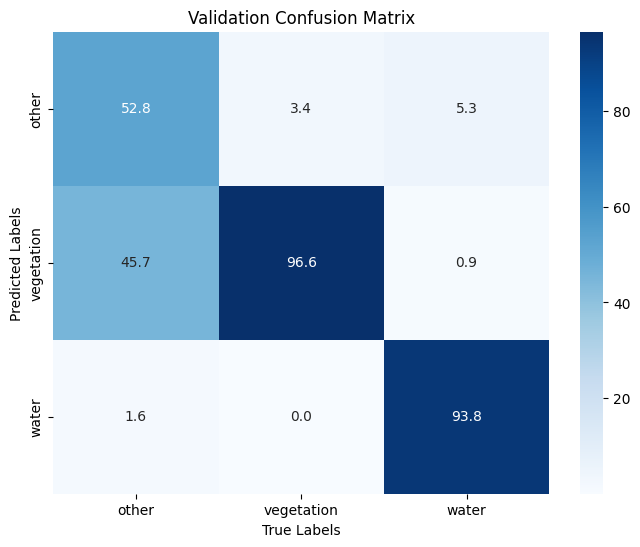

In [14]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix.float() / best_model_val_conf_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

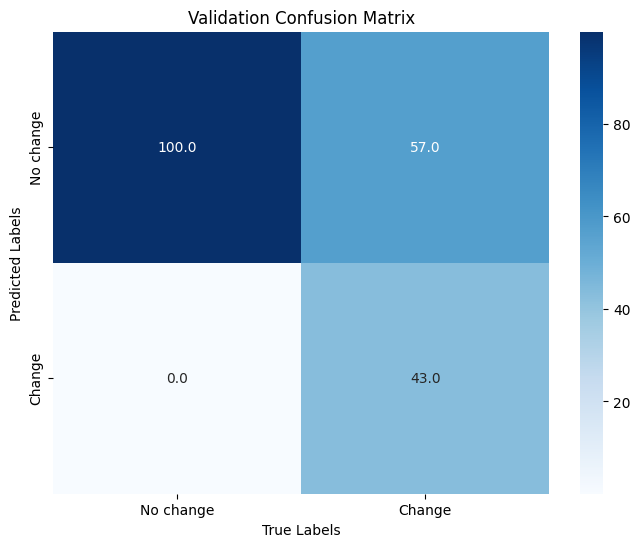

In [15]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix_change.float() / best_model_val_conf_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=["No change", "Change"], yticklabels=["No change", "Change"])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

In [16]:
canva_lab = torch.zeros(24, 256, 512).long()
canva_pred = torch.zeros(24, 256, 512).long()
canva_lab_change = torch.zeros(23, 256, 512).long()
canva_pred_change = torch.zeros(23, 256, 512).long()
ij_list = [[i, j] for i in range(4) for j in range(8)]
best_model_change.eval()
times = []
for k in range(len(test_set)):
    imgs, labs = test_set[k]
    imgs = imgs.to(device)
    with torch.no_grad():
        start = time.time()
        sem_logits, change_logits = best_model_change(imgs[None], DAYS[None])
        end = time.time()
        times.append(end-start)
    pred_sem =  torch.argmax(sem_logits[0], dim=1).detach().cpu()
    pred_change = torch.argmax(change_logits[0], dim=1).detach().cpu()
    labs = labs.detach().cpu()
    labs_change = (labs[:-1] != labs[1:]).long()
    i, j = ij_list[k]
    canva_lab[:, i*64:(i+1)*64, j*64:(j+1)*64] = labs
    canva_pred[:, i*64:(i+1)*64, j*64:(j+1)*64] = pred_sem
    canva_lab_change[:, i*64:(i+1)*64, j*64:(j+1)*64] = labs_change
    canva_pred_change[:, i*64:(i+1)*64, j*64:(j+1)*64] = pred_change

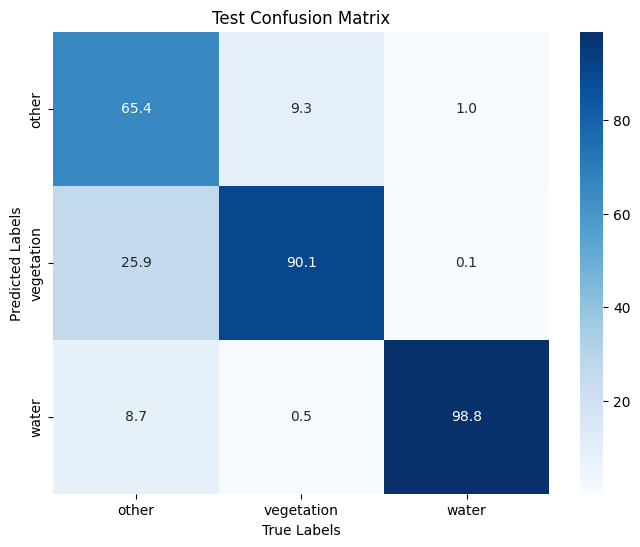

In [17]:
test_confusion_matrix = torch.bincount(canva_pred.flatten().long() * 3 + canva_lab.flatten().long(), minlength=9).reshape(3, 3)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_normalized = test_confusion_matrix.float() / test_confusion_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix')
plt.show()

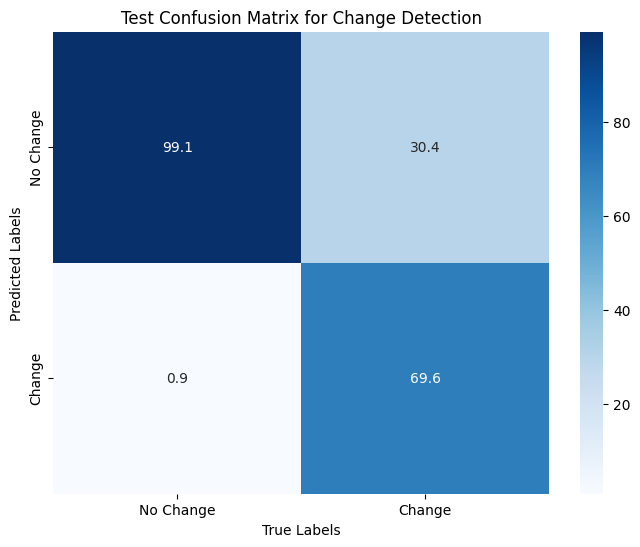

In [18]:
test_confusion_matrix_change = torch.bincount(canva_pred_change.flatten().long() * 2 + canva_lab_change.flatten().long(), minlength=4).reshape(2, 2)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_change_normalized = test_confusion_matrix_change.float() / test_confusion_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_change_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=['No Change', 'Change'], yticklabels=['No Change', 'Change'])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix for Change Detection')
plt.show()

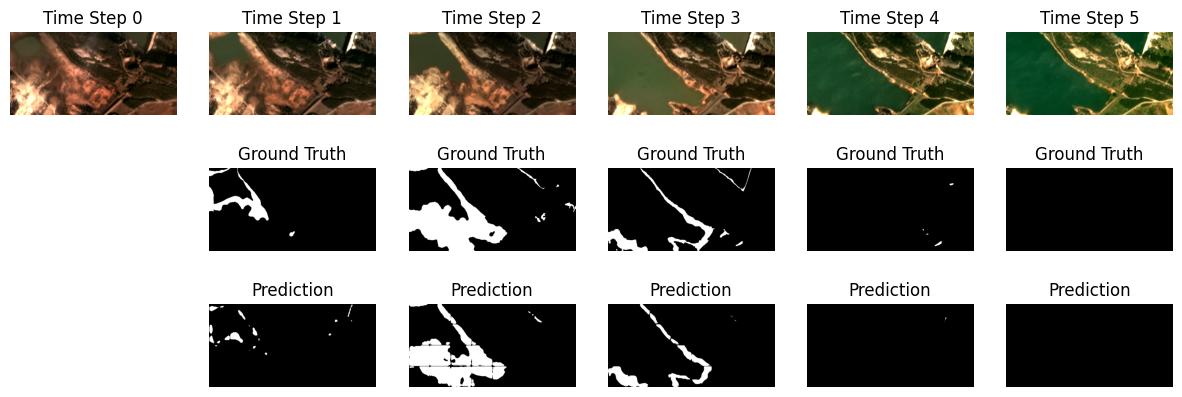

In [19]:
plt.figure(figsize=(15, 5))
for time_step in range(6):
    plt.subplot(3, 6, time_step + 1)
    plt.title(f"Time Step {time_step}")
    plot_image(images[time_step, :, 512:768:, :512])
    if time_step > 0:
        plt.subplot(3, 6, time_step + 7)
        plt.title(f"Ground Truth")
        plt.imshow(canva_lab_change[time_step].numpy(), cmap='gray')
        plt.axis('off')
        plt.subplot(3, 6, time_step + 13)
        plt.title(f"Prediction")
        plt.imshow(canva_pred_change[time_step].numpy(), cmap='gray')
        plt.axis('off')
plt.show()

In [20]:
change_iou = test_confusion_matrix_change[1, 1].float() / (test_confusion_matrix_change[1, 1].float() + test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 1].float())
false_positive_rate = test_confusion_matrix_change[1, 0].float() / (test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 0].float())
acc = test_confusion_matrix.diag().sum().item() / test_confusion_matrix.sum().item()
per_class_iou = test_confusion_matrix.diag() / (test_confusion_matrix.sum(dim=1) + test_confusion_matrix.sum(dim=0) - test_confusion_matrix.diag())
miou = per_class_iou.mean().item()
print(f"Test inference time: {np.mean(times)*1e3:.1f}ms ({np.std(times)*1e3:.1f}ms) per time series")
print(f"Sem Seg Acc:         {acc*100:.1f}")
print(f"Sem Seg mIoU:        {miou*100:.1f}")
print(f"Change IoU:          {change_iou.item() * 100:.1f}")
print(f"False Positive Rate: {false_positive_rate.item() * 100:.2f}")

Test inference time: 24.5ms (2.1ms) per time series
Sem Seg Acc:         87.6
Sem Seg mIoU:        75.7
Change IoU:          56.0
False Positive Rate: 0.91


| Method        | Inference Time (ms) | Sem. Seg. Acc. | Sem. Seg. mIoU | Change IoU | False Positive Rate |
|---------------|--------------------|----------------|----------------|------------|---------------------|
| UNet          | 356.1 (199.5) | 86.4 | 73.7 | 6.3 | 2.33 |
| DualUNet      | 20.0 (2.0) | 85.8 | 72.5 | 56.9 | 1.30 |
| MultiDualUNet | 17.4 (1.2) | 89.5 | 79.3 | 63.9 | 0.82 |

In [21]:
model = torch.hub.load('gastruc/UniverSat', 'from_pretrained').eval()

The repository gastruc_UniverSat does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/gastruc/UniverSat/zipball/main" to /root/.cache/torch/hub/main.zip


config.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  804MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
model.to('cuda')
model.eval()
device = 'cuda'

features = torch.zeros(24, 128, 128, 768)
ij_list = [[i, j] for i in range(4) for j in range(8)]
times = []
for k in range(len(test_set)):
    i, j = ij_list[k]
    if i < 2 and j < 2:
        imgs, labs = test_set[k]
        imgs = imgs.to(device)
        with torch.no_grad():
            start = time.time()
            output, _ = model.encode({"planet": imgs[:, :4], "s2": imgs[:, 4:]}, patch_size=40, output_grid=64)
            output = output.reshape(-1, 64, 64, 768)
            end = time.time()
            times.append(end-start)
            features[:, i*64:(i+1)*64, j*64:(j+1)*64] = output.cpu()

In [ ]:
from sklearn.decomposition import PCA

def patches_to_rgb_pca(
    patches: torch.Tensor,          # (B, N, D)
    grid_size: int = 64,            # sqrt(N)
) -> np.ndarray:                    # (B, H, W, 3)
    """
    Project patch embeddings to 3-D with PCA, reshape to a spatial grid,
    and normalise each channel to [0, 1] for display.
    """
    B, H, W, D = patches.shape
    flat = patches.reshape(B * H * W, D).numpy()  # (B*N, D)

    pca = PCA(n_components=3)
    rgb = pca.fit_transform(flat)             # (B*N, 3)

    # Normalise to [0, 1]
    rgb = (rgb - rgb.min(0)) / (rgb.max(0) - rgb.min(0) + 1e-8)

    # Reshape to spatial grid
    rgb = rgb.reshape(B, H, W, 3)
    return rgb

In [ ]:
# pca = patches_to_rgb_pca(features.cpu())
diff = ((features[:-1] - features[1:]) ** 2).mean(-1)
diff = diff / diff.max()

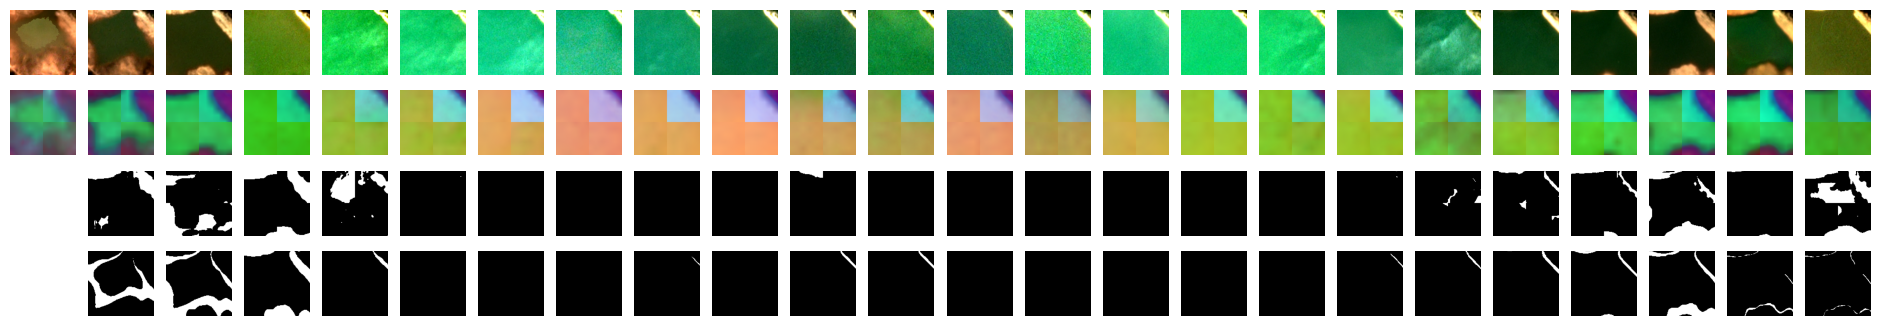

In [ ]:
plt.figure(figsize=(24, 4))
for time_step in range(24):
    plt.subplot(4, 24, time_step + 1)
    plot_image(images[time_step, :, 512:640, :128])
    plt.subplot(4, 24, 24 + time_step + 1)
    plt.imshow(pca[time_step])
    plt.axis('off')
    if time_step > 0:
        plt.subplot(4, 24, 48 + time_step + 1)
        plt.imshow(diff[time_step-1] > 0.2, vmin=0, vmax=1, cmap="gray")
        plt.axis('off')

        plt.subplot(4, 24, 72 + time_step + 1)
        plt.imshow((labels[:-1, 512:640, :128] != labels[1:, 512:640, :128]).astype(int)[time_step-1], vmin=0, vmax=1, cmap="gray")
        plt.axis('off')
plt.show()

### Bibliography

[1] Toker et al. _DynamicEarthNet: Daily Multi-Spectral Satellite Dataset for Semantic Change Segmentation_. CVPR 2022.